# Q5.
```{admonition}
:class: note
We have seen that we can fit an SVM with a non-linear kernel in order to perform classification using a non-linear decision boundary. We will now see that we can also obtain a non-linear decision boundary by performing logistic regression using non-linear transformations of the features.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

## (a)
```{admonition}
:class: note
Generate a data set with $n = 500$ and $p = 2$, such that the observations belong to two classes with a quadratic decision boundary between them.

In [3]:
rng = np.random.default_rng(1728)
x1 = rng.uniform(-1,1,size=500)
x2 = rng.uniform(-1,1,size=500)

classes = (4*x1**2-x2<0.5).astype(int)

df = pd.DataFrame({'x1':x1,'x2':x2,'class':classes})

## (b)
```{admonition}
:class: note
Plot the observations, colored according to their class labels.

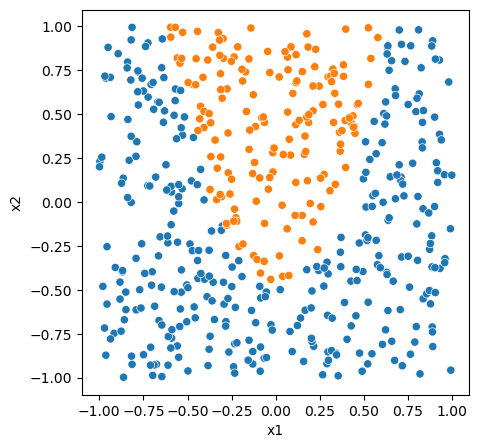

In [4]:
plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x='x1',y='x2',hue='class',legend=False)
plt.show()

## (c)
```{admonition}
:class: note
Fit a logistic regression model to the data, using $X_{1}$ and $X_{2}$ as predictors

In [5]:
logr = LogisticRegression()
logr.fit(df[['x1','x2']],df['class'])

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## (d)
```{admonition}
:class: note
Apply this model to the *training data* in order to obtain a predicted class label for each training observation. Plot the observations, colored according to the *predicted* class labels. The decision boundary should be linear.

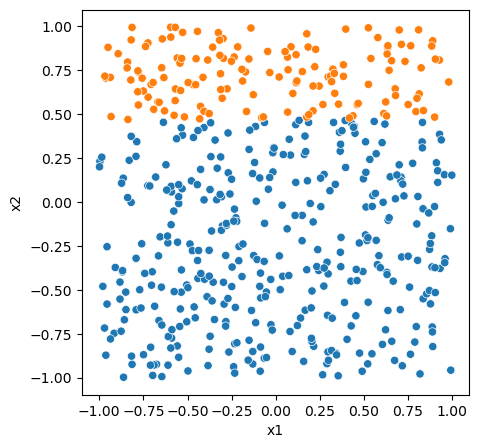

In [6]:
plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x='x1',y='x2',hue=logr.predict(df[['x1','x2']]),legend=False)
plt.show()

## (e)
```{admonition}
:class: note
Now fit a logistic regression model to the data using non-linear functions of $X_{1}$ and $X_{2}$ as predictors.

In [7]:
df_nonlin = df.copy()
df_nonlin['x1*x2'] = df_nonlin['x1']*df_nonlin['x2']
df_nonlin['log |x2|'] = np.log(np.abs(df_nonlin['x2']))
df_nonlin['x1^4'] = df_nonlin['x1']**4

## (f)
```{admonition}
:class: note
Apply this model to the *training data* in order to obtain a predicted class label for each training observation. Plot the observations, colored according to the *predicted* class labels.

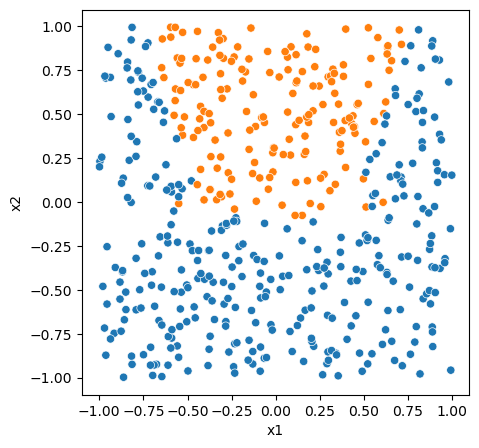

In [8]:
logr_nonlin = LogisticRegression()
logr_nonlin.fit(df_nonlin.drop(columns=['class']),df_nonlin['class'])

plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x='x1',y='x2',hue=logr_nonlin.predict(df_nonlin.drop(columns=['class'])),legend=False)
plt.show()

## (g)
```{admonition}
:class: note
Fit a support vector classifier to the data with $X_{1}$ and $X_{2}$ as predictors. Obtain a class prediction for each training observation. Plot the observations, colored according to the *predicted class labels*.

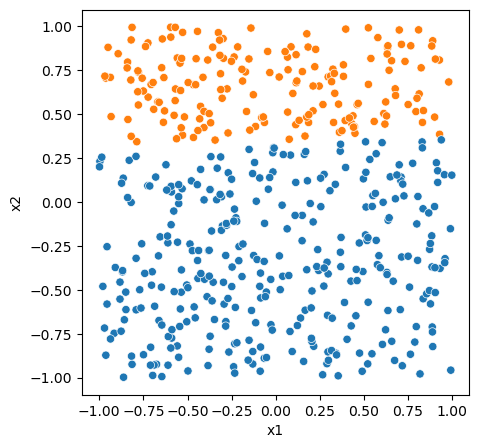

In [9]:
svc_lin = svm.SVC(kernel='linear')
svc_lin.fit(df[['x1','x2']],df['class'])

plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x='x1',y='x2',hue=svc_lin.predict(df[['x1','x2']]),legend=False)
plt.show()

## (h)
```{admonition}
:class: note
Fit an SVM using a non-linear kernel to the data. Obtain a class prediction for each training observation. Plot the observations, colored according to the *predicted class labels*.

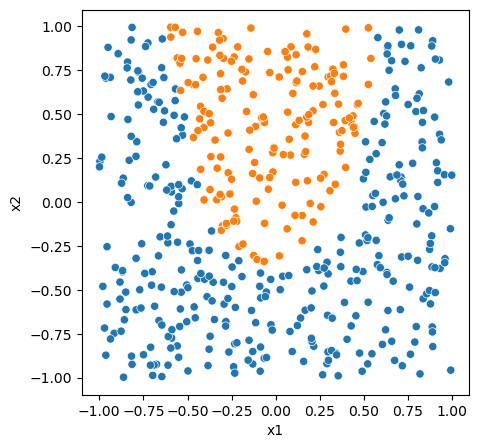

In [10]:
svc_rad = svm.SVC(kernel='rbf')
svc_rad.fit(df[['x1','x2']],df['class'])

plt.figure(figsize=(5,5))
sns.scatterplot(data=df,x='x1',y='x2',hue=svc_rad.predict(df[['x1','x2']]),legend=False)
plt.show()

<div class="question">
(i) Comment on the results.

The linear kernel and logistic regression give very similar linear boundaries that do not match the true decision boundary. Using a radial kernel gave a much better match. Adding a few non-linear terms to the logistic regression also provided a better match. The shape of this boundary is not as close to the true one; however, given the terms added to the model did not include the correct quadratic term needed it performed well regardless.